# Normalizing FlowsIntroduction to normalizing flows for density estimation.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn import AdditiveCouplingFlow, AffineAutoregressiveFlow, SplineAutoregressiveFlow
from probjax.stats.bijective import affine_bijector, additive_bijector
from probjax.nn.nets.autoregressive import AutoregressiveMLP
from probjax.core import inverse, inverse_and_logabsdet


In [3]:

def affine_bijector(params, x):
    x = jnp.asarray(x)
    params = jnp.reshape(params, x.shape)
    return params + x


def scale_bijector(params, x):
    return jnp.exp(params) * x


In [4]:
model = AutoregressiveMLP(1,1, affine_bijector,hidden_dims=[100], rngs=nnx.Rngs(1))
batch_shape = (5, 1,2)
in_dim = 1
out_dim = 1
x = jnp.ones(batch_shape + (in_dim,))
y = model(x)
assert y.shape == batch_shape + (out_dim,)

def loss_fn(model):
    return jnp.sum(model(x))

# Can be differentiated
_ = jax.grad(loss_fn)

# Can be flattened
_, _ = jax.tree_util.tree_flatten(model)

# Test inverse
model_inv = inverse(model)
y_inv = model_inv(y)
assert jnp.allclose(x, y_inv), " Inverse is not correct"

In [5]:
p = AffineAutoregressiveFlow(4, 2, nnx.Rngs(1))

graph_def, params, state = nnx.split(p, nnx.Param,...)


In [6]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [7]:
def loss(params):
    p = nnx.merge(graph_def, params, state)
    return -jnp.mean(p.logpdf(xs))

In [8]:
loss(params)

Array(13.666442, dtype=float32)

In [9]:
import optax

optimizer = optax.adam(5e-4)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [10]:
opt_state = optimizer.init(params)

In [12]:
for i in range(10000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

13.666442
13.574314
13.482514
13.390825
13.299188
13.207614
13.116116
13.024718
12.933457
12.842374
12.751507
12.660905
12.570618
12.480701
12.39121
12.302204
12.213739
12.125881
12.03869
11.952228
11.866555
11.781732
11.697817
11.61487
11.532943
11.45209
11.372364
11.293807
11.216467
11.140384
11.06559
10.99212
10.92
10.849257
10.779902
10.711952
10.645416
10.580299
10.516594
10.454301
10.393413
10.333909
10.275776
10.218997
10.163543
10.109391
10.056514
10.004879
9.954459
9.905221
9.85713
9.810155
9.764262
9.71942
9.675595
9.632755
9.590868
9.549901
9.50983
9.470622
9.432251
9.39469
9.357915
9.321898
9.286624
9.252062
9.218198
9.185008
9.152477
9.120586
9.089321
9.058661
9.028596
8.99911
8.97019
8.941823
8.913997
8.8867
8.859922
8.833649
8.807874
8.782584
8.75777
8.733422
8.709529
8.686085
8.6630745
8.640492
8.618327
8.596572
8.575214
8.554245
8.533657
8.513438
8.49358
8.4740715
8.454906
8.436076
8.417567
8.39937
8.38148
8.363886
8.346577
8.329545
8.312781
8.296277
8.2800255
8.264015

In [13]:
nnx.update(p, params)

In [14]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

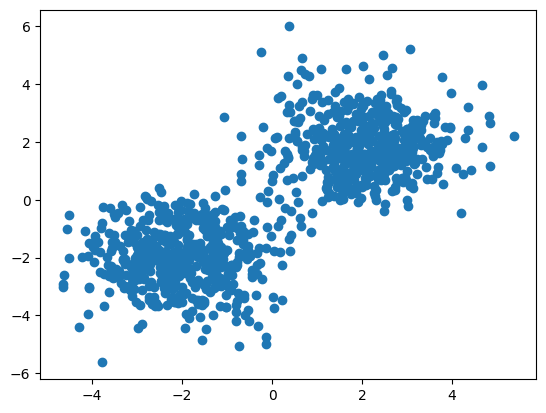

In [15]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])